In [1]:
from pathlib import Path
from skbio.stats import composition
import pandas as pd
import numpy as np
import sklearn
import squidpy as sq
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append('../../scripts')

import readwrite
cfg = readwrite.config()

def concat_samples(ads, correction_method, segmentation, condition=None, panel=None):
    ads_corr_method = ads[correction_method]

    def is_match(key):
        return (
            segmentation in key and
            (condition is None or condition in key) and
            (panel is None or panel in key)
        )

    adata = sc.concat({k: v for k, v in ads_corr_method.items() if is_match(k)},label='dataset_id', join='outer')
    adata.obs[xenium_levels] = pd.DataFrame(adata.obs['dataset_id'].tolist(),index=adata.obs.index,columns=xenium_levels)
    return adata


# def sparse_to_knn(A):
#     """
#     Converts a sparse adjacency matrix into a list of NumPy arrays.
#     """
#     knnidx = A.tolil().rows
#     return knnidx

def sparse_to_knn(A):
    # Extract row (samples), col (indices of neighbors), and data (distances)
    row_indices = A.indices
    row_ptrs = A.indptr
    distances = A.data

    # Prepare empty lists for knnidx and knndist
    knnidx = []
    knndist = []

    # Loop over each row (sample) to extract the neighbor indices and distances
    for i in range(A.shape[0]):
        start, end = row_ptrs[i], row_ptrs[i + 1]
        knnidx.append(row_indices[start:end])    # Neighbor indices for i-th sample
        knndist.append(distances[start:end])     # Corresponding distances for i-th sample

    # Convert lists to numpy arrays (optional)
    knnidx = np.array(knnidx, dtype=object)
    knndist = np.array(knndist, dtype=object)

    return knnidx, knndist


def get_knn_labels(knnidx, dummy_array):
    # Convert df_dummies to a numpy array for efficient indexing
    if not isinstance(dummy_array, np.ndarray):
        dummy_array = np.array(dummy_array)

    if knnidx.ndim == 2:
        # knnidx contains same length list of neighbor indices for each sample
        knnlabels = dummy_array[knnidx].sum(1)
    else:
        # Initialize an empty list to store the summed labels
        knnlabels = []

        # Loop over each row in knnidx
        for neighbors in knnidx:
            # Get the one-hot encoded labels for the current neighbors
            neighbor_labels = dummy_array[neighbors]

            # Sum the labels across the neighbors (axis=0 sums column-wise)
            summed_labels = neighbor_labels.sum(axis=0)

            # Append the summed labels to the list
            knnlabels.append(summed_labels)

        # Convert the list back to a numpy array (optional)
        knnlabels = np.array(knnlabels)

    return knnlabels


def _helmert_contrast(n):
    """Helmert contrasts.
    This is equivalent to R's `contr.helmert`.
    """
    contr = np.zeros((n, n - 1))
    contr[1:][np.diag_indices(n - 1)] = np.arange(1, n)
    contr[np.triu_indices(n - 1)] = -1
    return contr


def ilr(x, p=0):
    """
    performs an isometric log-ratio transformation on the input data x.
    It first takes the natural logarithm of x, then applies a Box-Cox transformation if the parameter p is not equal to 0.
    After that, it re-centers the values and applies a Helmert contrast transformation.
    Finally, it returns the dot product of the transformed y and the transpose of the Helmert transformation matrix.
    https://stats.stackexchange.com/questions/259208/how-to-perform-isometric-log-ratio-transformation
    """
    y = np.log(x)
    if p != 0:
        y = (np.exp(p * y) - 1) / p  # Box-Cox transformation
    y -= np.mean(y, axis=1, keepdims=True)  # Recentered values
    k = y.shape[1]
    H = _helmert_contrast(k)
    H = H.T / np.sqrt(np.arange(2, k + 1) * np.arange(1, k)).reshape(-1, 1)

    return np.dot(y, H.T)
    
# def ilr(X_composition):
#     X_nz = composition.multi_replace(X_composition)
#     X_ilr = ilr(X_nz)
#     return X_ilr


def get_ilr(
    adata,
    radius=20,
    p=0.,
    label_key="cell_type",
    knn_key="X_spatial",
    knnidx=None,
):
    """
    Generate the isometric log ratio (ILR) transformation.

    Args:
        adata: Anndata object containing spatial transcriptomics data coordinates in .obsm['X_spatial'].
        n_neighbors: Number of nearest neighbors to consider for the ILR transformation (default is 20).
        p: Parameter for the ILR Box-Cox transformation (default is 0.5).
        label_key: Key in .obs containing labels.
        knn_key: Key in .obsm containing data coordinates to compute neighbors (default is 'X_spatial').

    Returns:
        knnlabels: DataFrame containing the ILR-transformed spatial transcriptomics data.
        adata.obsm['X_ilr'] : ILR-transformed spatial transcriptomics data.
        adata.obsm['X_ilr_pca'] : PCA-transformed ILR-transformed spatial transcriptomics data.
        adata.uns['ilr_pca'] : PCA attributes.
    """

    if knnidx is None:
        knndis, knnidx = (
            sklearn.neighbors.NearestNeighbors(radius=radius)
            .fit(adata.obsm[knn_key])
            .radius_neighbors()
        )
    df_dummies = pd.get_dummies(adata.obs[label_key])
    adata.obsm["X_knnlabels"] = get_knn_labels(knnidx, df_dummies)
    adata = adata[adata.obsm["X_knnlabels"].sum(1) > 5].copy()

    adata.obsm["X_composition"] = adata.obsm["X_knnlabels"] / adata.obsm["X_knnlabels"].sum(1, keepdims=1)


    adata.obsm["X_composition_nz"] = composition.multi_replace(adata.obsm["X_composition"])

    adata.obsm["X_ilr"] = ilr(adata.obsm["X_composition_nz"],p=p)

    pca = sklearn.decomposition.PCA().fit(adata.obsm["X_ilr"])
    adata.obsm["X_ilr_pca"] = pca.transform(adata.obsm["X_ilr"])
    adata.uns["ilr_pca"] = pca.__dict__
    adata.uns["X_knnlabels_columns"] = df_dummies.columns
    return adata

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this pac

### Read all xenium samples

In [4]:
# input params
correction_method = 'raw'
segmentation = 'proseg_expected'
condition = 'CRC'
panel = 'hImmune_v1_mm'

xenium_dir = Path(cfg['xenium_processed_dir'])
xenium_count_correction_dir = Path(cfg['xenium_count_correction_dir'])
xenium_std_seurat_analysis_dir = Path(cfg['xenium_std_seurat_analysis_dir'])
xenium_cell_type_annotation_dir = Path(cfg['xenium_cell_type_annotation_dir'])
results_dir = Path(cfg['results_dir'])

xenium_levels = ['segmentation','condition','panel','donor','sample']
normalisation = 'lognorm'
reference = 'GEO_GSE236581' # 'GEO_GSE178341'
method = 'rctd_class_aware'
level = 'Level1'


# fixed params
BATCH_KEY = 'dataset_id'
SPATIAL_KEY = 'spatial'
N_CLUSTERS_RANGE = (5,19)
MAX_RUNS = 10
CONVERGENCE_TOL = 0.001
OUTPUT_LABELS = results_dir/'xenium/cellcharter/labels.parquet'
OUTPUT_SCVI_MODEL = results_dir/'xenium/cellcharter/scvi_model'
OUTPUT_CELLCHARTER_MODELS = results_dir/'xenium/cellcharter/cellcharter_models'
OUTPUT_PLOT = results_dir/'xenium/cellcharter/autok_stability.png'



# read samples
xenium_paths, xenium_annot_paths = readwrite.discover_xenium_paths(
    analysis_dir=xenium_std_seurat_analysis_dir,
    data_dir=xenium_dir,
    annotation_dir=xenium_cell_type_annotation_dir,
    correction_dir=xenium_count_correction_dir,
    normalisation=normalisation,
    reference=reference,
    method=method,
    level=level,
    correction_methods_filter=[correction_method],
    segmentations_filter=[segmentation],
    conditions_filter=[condition] if condition != 'all' else None,
    panels_filter=[panel] if panel != 'all' else None
)


# set transcripts=True to load individual transcripts positions)
if correction_method != 'raw':
    ads = readwrite.read_count_correction_samples(xenium_paths,[correction_method])
else:
    ads = {}
    ads['raw'] = readwrite.read_xenium_samples(
        xenium_paths['raw'],  
        anndata=True, 
        pool_mode="thread",
        max_workers=6
    )

# add cell type annotation from raw to all correction methods
readwrite.read_annotations(ads, [correction_method], xenium_annot_paths, level, max_workers=8)

# concat samples
adata = sc.concat({k: v for k, v in ads[correction_method].items() },label='dataset_id', join='outer')
adata.obs[xenium_levels] = pd.DataFrame(adata.obs['dataset_id'].tolist(),index=adata.obs.index,columns=xenium_levels)
adata.obs['correction_method'] = correction_method

# info about the loaded cohort
df_cohort_info = pd.DataFrame([k+(corr_method,) for corr_method in [correction_method] for k in ads[corr_method].keys() ], columns=xenium_levels+['correction_method'])

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_polygons', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:831: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

Could not find annotation file for ('proseg_expected', 'CRC', 'hImmune_v1_mm', '03FO', 'HCC_output-XETG00209__0003786__03F0__20250503__073331'): /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/cell_type_annotation/proseg_expected/CRC/hImmune_v1_mm/03FO/HCC_output-XETG00209__0003786__03F0__20250503__073331/lognorm/reference_based/GEO_GSE236581/rctd_class_aware/Level1/single_cell/labels.parquet
Could not find annotation file for ('proseg_expected', 'CRC', 'hImmune_v1_mm', '19II', 'output-XETG00059__0053259__19II__20250306__164822'): /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/cell_type_annotation/proseg_expected/CRC/hImmune_v1_mm/19II/output-XETG00059__0053259__19II__20250306__164822/lognorm/reference_based/GEO_GSE236581/rctd_class_aware/Level1/single_cell/labels.parquet


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


# overall composition

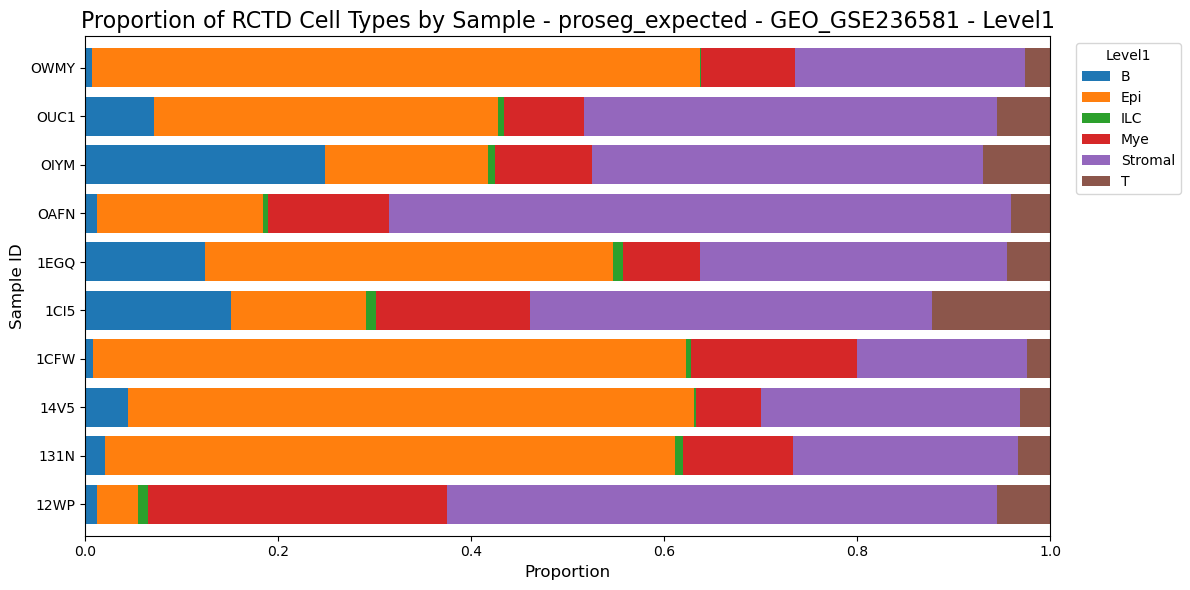

In [5]:
df_props = (
    adata.obs
    .groupby(xenium_levels)['Level1']
    .value_counts(normalize=True)
    .unstack()
    .reset_index()
)
df_props['full_sample_id'] = df_props[xenium_levels].astype(str).agg(' | '.join, axis=1)
df_props = df_props.query(f"segmentation == '{segmentation}'")

# Step 2: Dynamically set the figure size
num_samples = len(df_props.index)
fig_height = max(6, num_samples * 0.4) 

# Step 3: Create the figure and axes object
fig, ax = plt.subplots(figsize=(12, fig_height))

# Step 4: Plot directly onto the created axes object
df_props.query(f"segmentation == '{segmentation}'").plot(
    kind='barh',
    stacked=True,
    ax=ax,
    width=0.8
)


# Step 6: Customize the plot
ax.set_title(f'Proportion of RCTD Cell Types by Sample - {segmentation} - {reference} - {level}', fontsize=16)
ax.set_xlabel('Proportion', fontsize=12)
ax.set_ylabel('Sample ID', fontsize=12)
ax.set_yticklabels(df_props['donor'])
ax.legend(title='Level1', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

df_props.to_csv(f'../../scratch/celltype_composition_{segmentation}_{reference}_{level}.csv')

# coda

In [ ]:
adata.obs['sample']=adata.obs['sample'].astype('category')
sq.gr.spatial_neighbors(adata, radius=20, spatial_key='spatial',library_key='sample',coord_type='generic',set_diag=True)

knnidx,knndist = sparse_to_knn(adata.obsp['spatial_connectivities'])
adata_ilr = get_ilr(adata, knnidx=knnidx, label_key=level)

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [48]:
sc.pp.subsample(adata_ilr,n_obs=50_000)
sc.pp.neighbors(adata_ilr,use_rep='X_ilr_pca',metric='euclidean')
sc.tl.umap(adata_ilr,min_dist=.8)

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.1

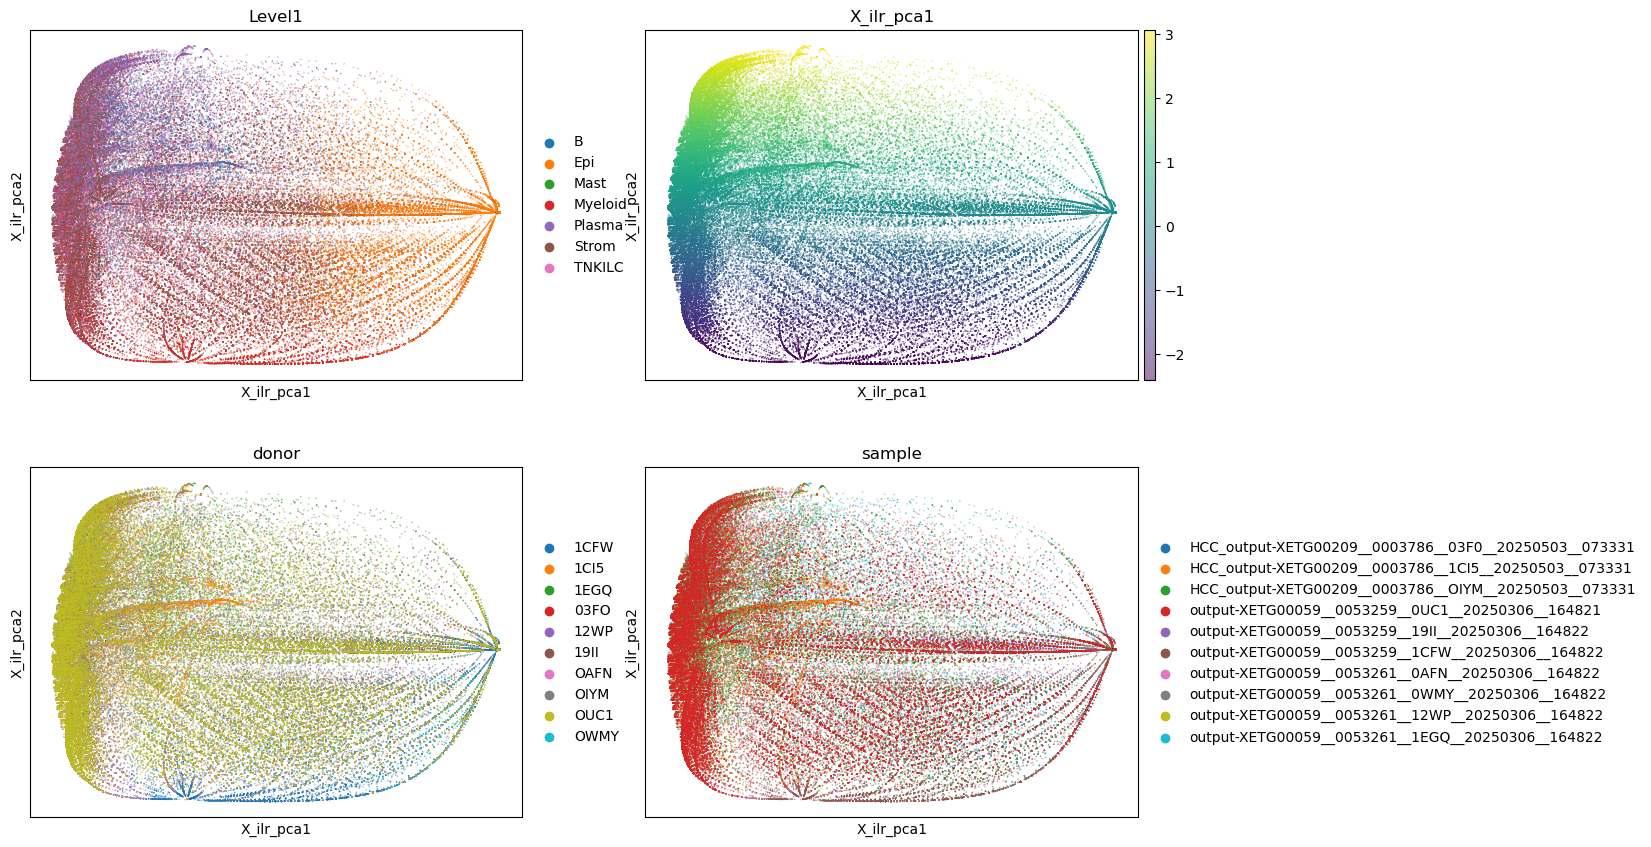

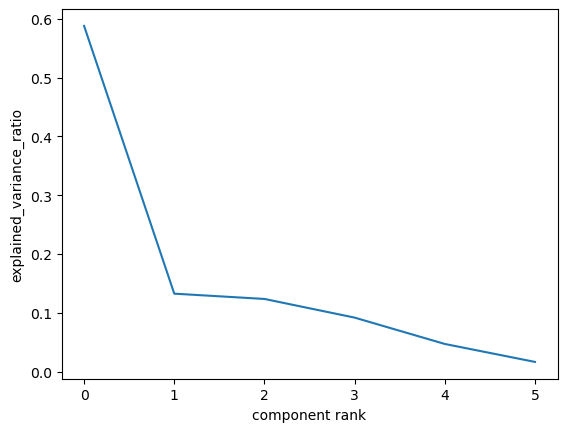

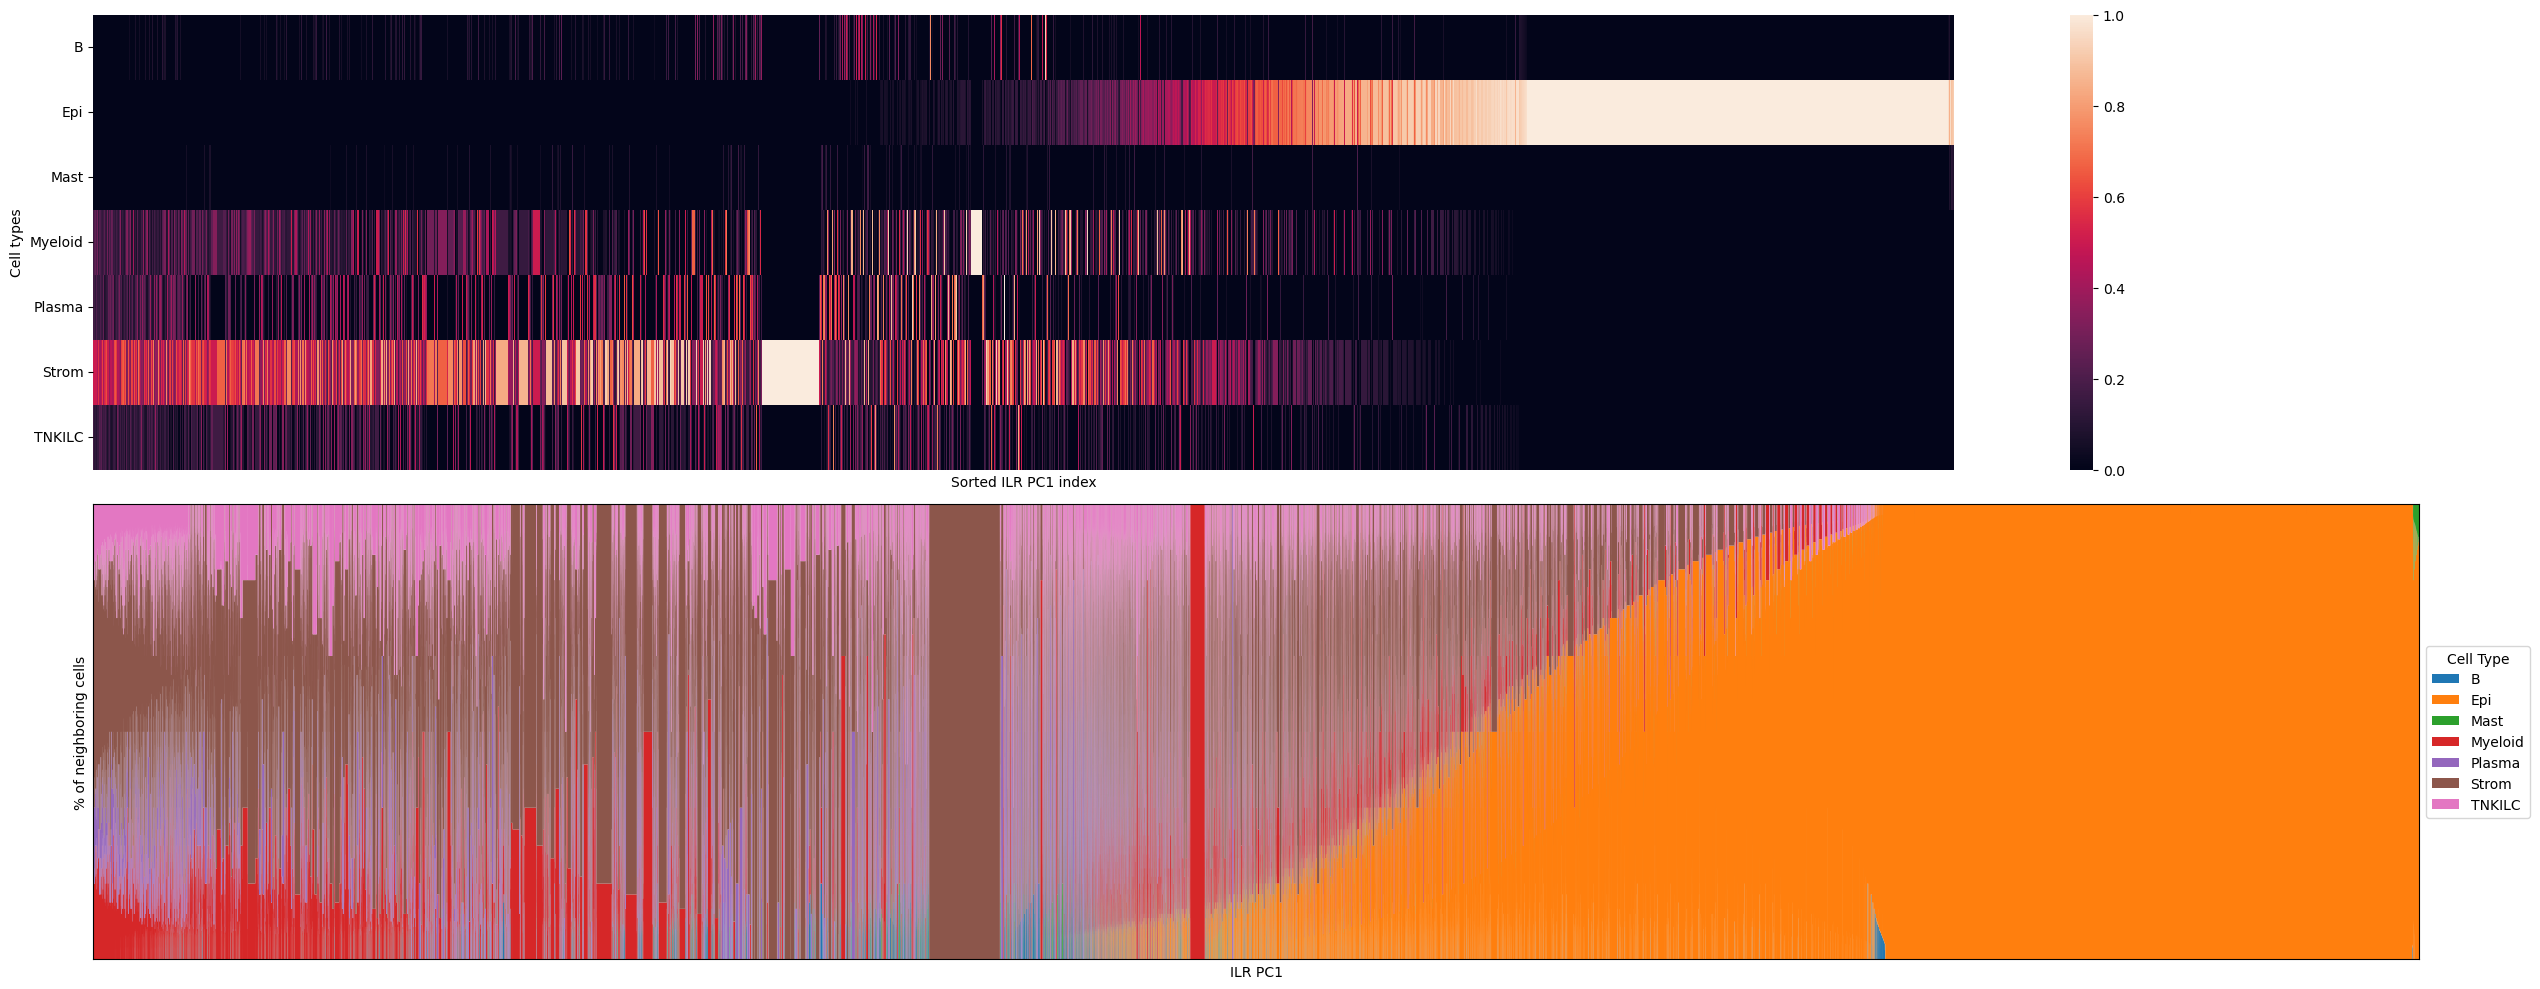

In [ ]:
cols = [level,'condition','donor','sample']

for i in range(2):
    adata_ilr.obs[f'X_ilr_pca{i}'] = adata_ilr.obsm['X_ilr_pca'][:,i]

sc.pl.embedding(adata_ilr,'X_ilr_pca',color=cols,s=5,alpha=.5,ncols=2)
# sc.pl.umap(adata_ilr,color=cols,s=5,alpha=.5,ncols=2)


plt.plot(adata_ilr.uns['ilr_pca']['explained_variance_ratio_'])
plt.ylabel('explained_variance_ratio')
plt.xlabel('component rank')
plt.show()


# sort by PC1 and normalize to 1
PC1 = adata_ilr.obsm['X_ilr_pca'][:,0]
df_plot = pd.DataFrame(adata_ilr.obsm['X_composition'],columns=adata_ilr.uns['X_knnlabels_columns'])
df_plot = df_plot.iloc[np.argsort(PC1)].T
df_plot.columns = np.arange(df_plot.shape[1])


f, axs = plt.subplots(2,1,figsize=(30,10))

ax = axs[0]
ax = sns.heatmap(data=df_plot,ax=ax)
ax.set_xticks([])
ax.set_yticklabels(df_plot.index, rotation = 0)
ax.set_ylabel('Cell types')
ax.set_xlabel('Sorted ILR PC1 index')


ax = axs[1]
ax.stackplot(df_plot.columns, *df_plot.values, labels=df_plot.index)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel('% of neighboring cells')
ax.set_xlabel('ILR PC1')
ax.legend(
    title='Cell Type', 
    loc='center left', 
    bbox_to_anchor=(1.0, 0.5)
)
ax.margins(x=0, y=0)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.show()

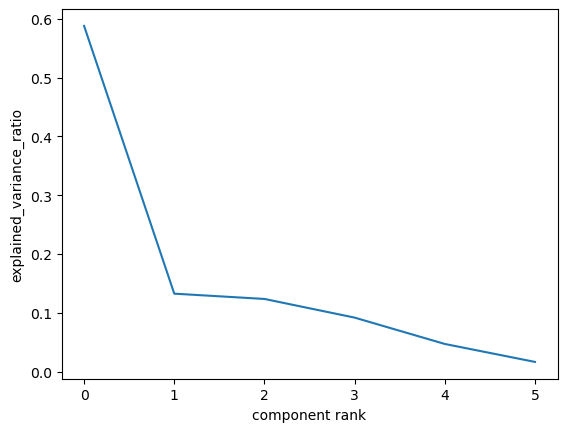

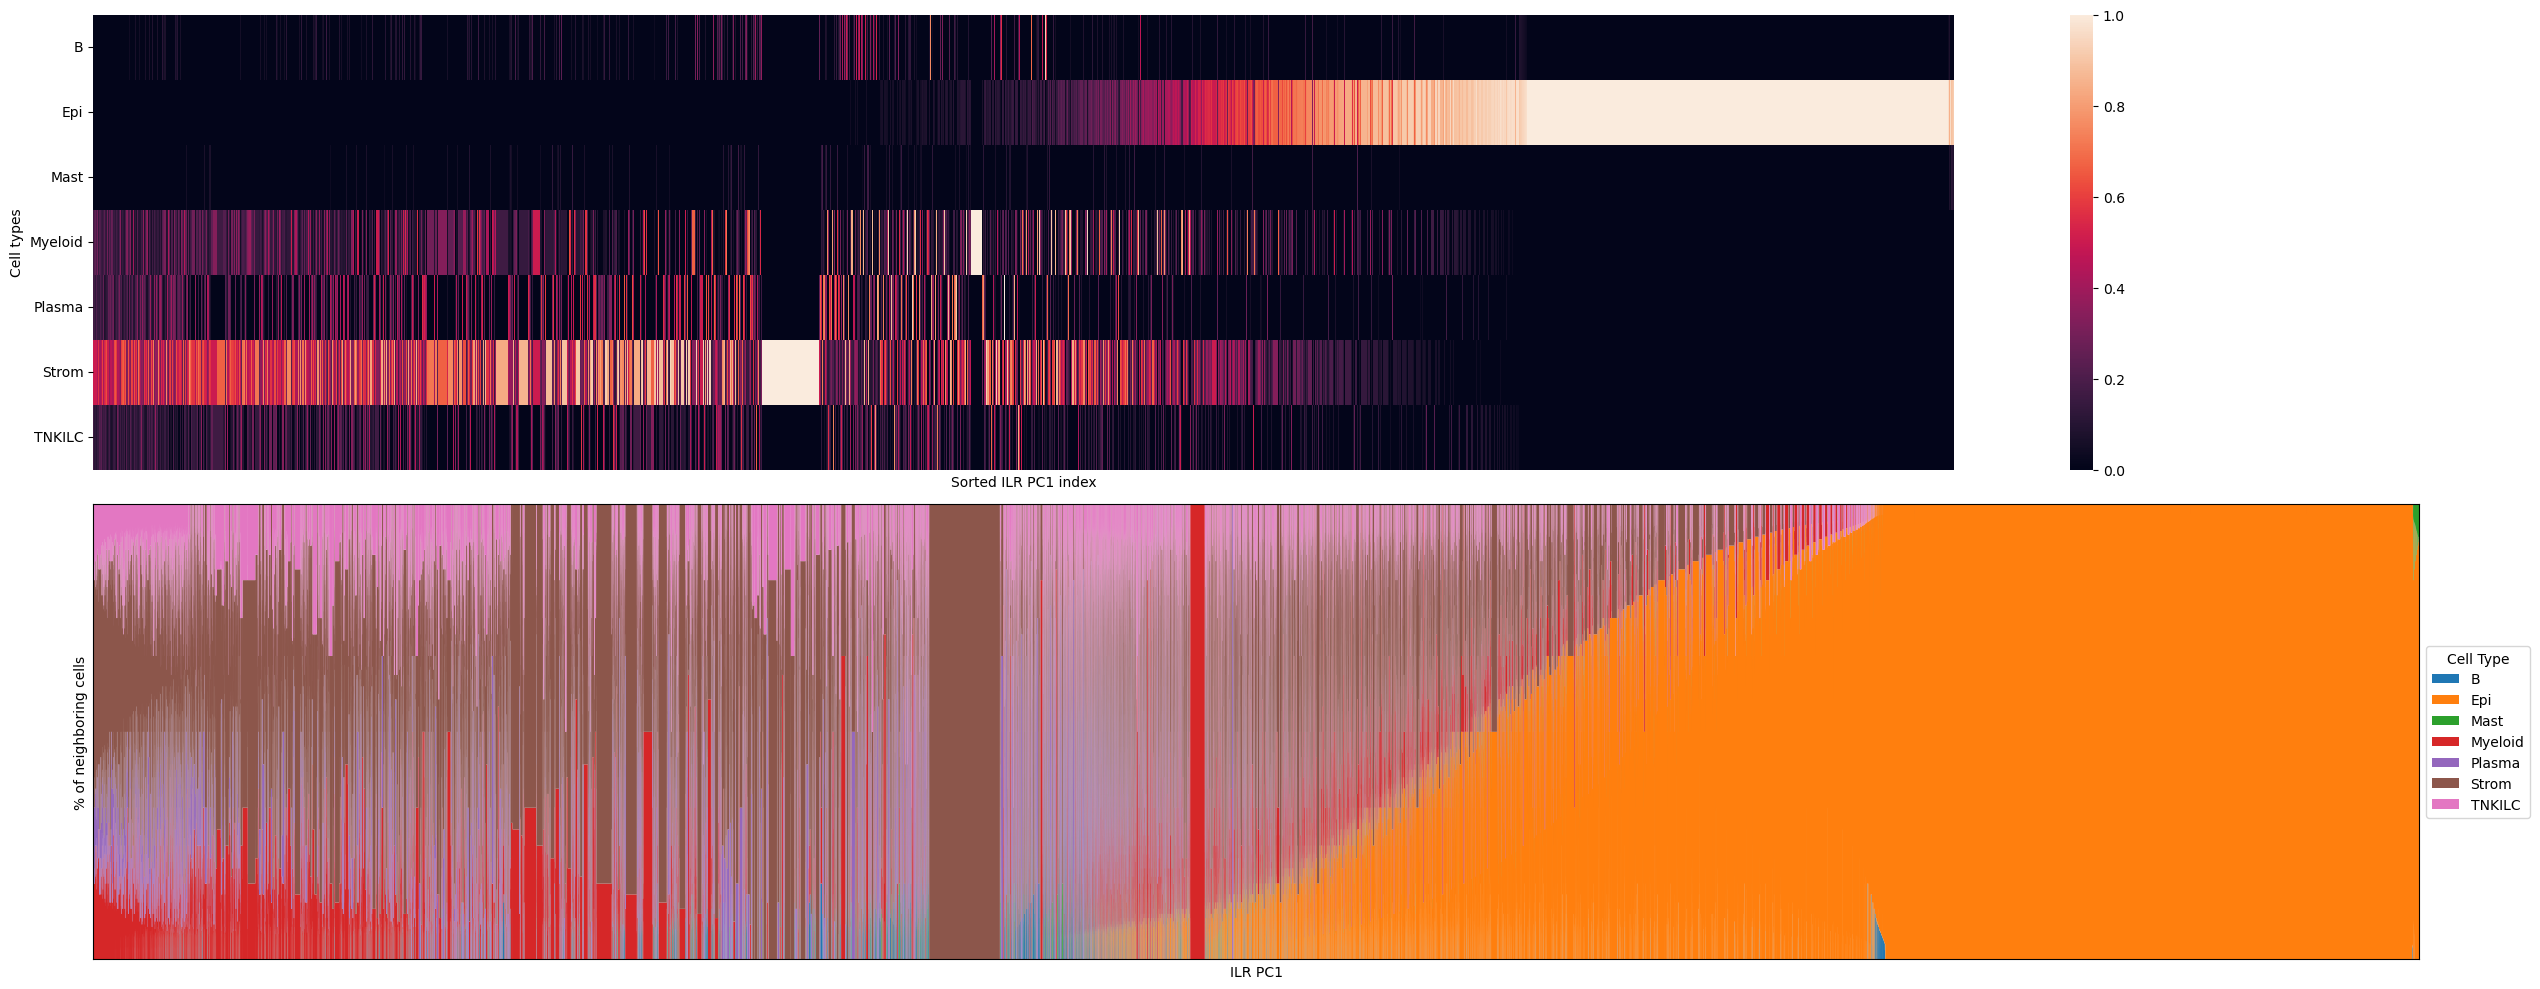

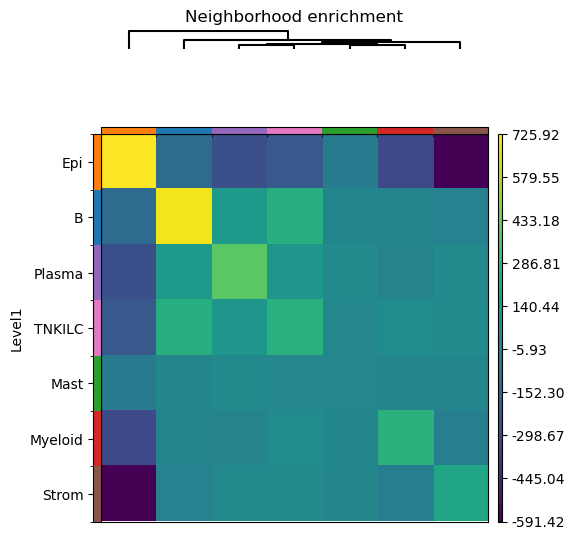

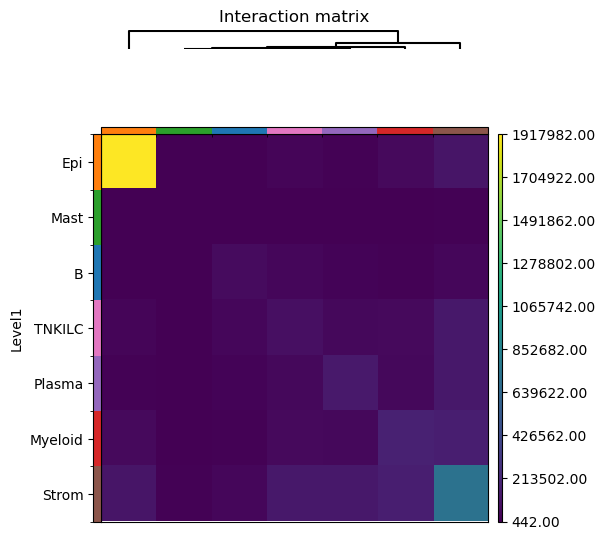

In [37]:
sq.gr.nhood_enrichment(adata_ilr, cluster_key=level)
sq.gr.interaction_matrix(adata_ilr, cluster_key=level)
# sq.gr.co_occurrence(adata_ilr, cluster_key=level)
sq.pl.nhood_enrichment(adata_ilr, cluster_key=level, method="average", figsize=(5, 5))
sq.pl.interaction_matrix(adata_ilr, cluster_key=level, method="average", figsize=(5, 5))
# sq.pl.co_occurrence(adata_ilr, cluster_key=level, clusters="B", figsize=(8, 5))